<a href="https://www.kaggle.com/code/feyisahabtamu11/the-cardio-performance-analysis?scriptVersionId=309316908" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/feyisahabtamu11/csec-data1/dataset-2.csv
/kaggle/input/datasets/feyisahabtamu11/csec-data1/dataset-1.csv


In [2]:
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv("/kaggle/input/datasets/feyisahabtamu11/csec-data1/dataset-1.csv")
data.head()


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


**Task 1: The Wealth Gap.** Calculate the Mean, Median, and Mode for Income.

Analysis: Is the data skewed? Explain what the difference between the mean and median tells you about the "typical" customer’s wealth.

In [4]:
mean_income = np.mean(data['Income'])
print(f"The mean value of the income is : {mean_income}")

median_income = np.median(data['Income'])
print(f"The meadian value of the income is : {median_income}")

from scipy import stats
mode_income = stats.mode(data['Income'])
mode_income = float(mode_income.mode)
print(f"The mode value of the income is : {mode_income}")

Hidden_description =  """
For analysis:
     Is the data skewed?
       ~ Yes, the data is Right-Skewed (Positively Skewed).

    Explain what the difference between the mean and median tells you about the "typical" customer’s wealth.
       ~ The Impact of Outliers: The mean is highly sensitive to extreme values. 
        The fact that the mean is higher than the median tells us there is a 
        group of high-income "outliers" in the dataset. These wealthy customers
        are pulling the average (mean) upward, even though they do not represent the majority.

       ~ The "Typical" Customer: The Median is the better representative of the "typical" 
        customer's wealth. It tells us that 50% of the customers earn less than $50,597$ 
        and 50% earn more.

"""



The mean value of the income is : 53719.57777777778
The meadian value of the income is : 50596.5
The mode value of the income is : 45480.0


**Task 2: The 5-Number Summary.** Display the min, Q1, median, Q3, and max for the Miles column.

Visualization: Create a Boxplot for Miles. Identify if there are any "Outliers" (dots beyond the whiskers). A box plot showing quartiles and outliers.

The minimum value of the Miles is : 21
The Q1 value of the Miles is : 66.0
The median value of the Miles is : 94.0
The Q3 value of the Miles is : 114.75
The maximum value of the Miles is : 360


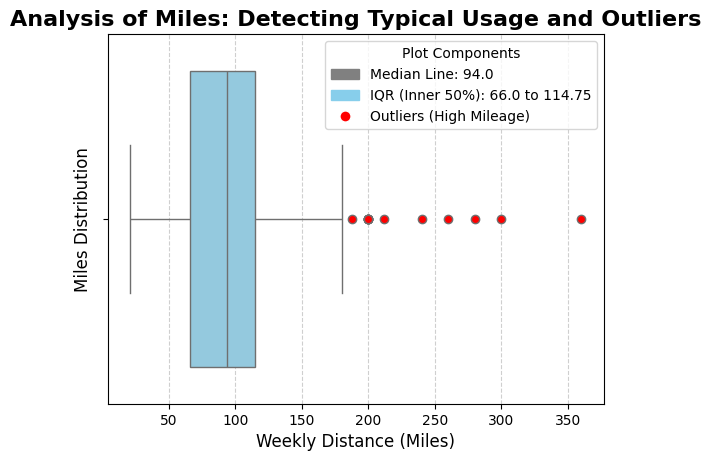

In [5]:
min_miles = np.min(data['Miles'])
print(f"The minimum value of the Miles is : {min_miles}")
q1_miles = np.percentile(data['Miles'], 25)
print(f"The Q1 value of the Miles is : {q1_miles}")
median_miles = np.median(data['Miles'])
print(f"The median value of the Miles is : {median_miles}")

q3_miles = np.percentile(data['Miles'], 75)
print(f"The Q3 value of the Miles is : {q3_miles}")

max_miles = np.max(data['Miles'])
print(f"The maximum value of the Miles is : {max_miles}")

# --- Visualization Part ---
sns.boxplot(x=data['Miles'], color='skyblue', flierprops={'markerfacecolor':'red', 'marker':'o'})

# 1. Add Titles and Axis Labels
plt.title('Analysis of Miles: Detecting Typical Usage and Outliers', fontsize=16, fontweight='bold')
plt.xlabel('Weekly Distance (Miles)', fontsize=12)
plt.ylabel('Miles Distribution', fontsize=12)

# 2. Add a Custom Legend
# Boxplots don't have a built-in legend, so we create one for clarity
median_patch = mpatches.Patch(color='gray', label=f'Median Line: {median_miles}')
box_patch = mpatches.Patch(color='skyblue', label=f'IQR (Inner 50%): {q1_miles} to {q3_miles}')
outlier_patch = plt.Line2D([0], [0], marker='o', color='w', label='Outliers (High Mileage)', 
                          markerfacecolor='red', markersize=8)

plt.legend(handles=[median_patch, box_patch, outlier_patch], loc='upper right', title="Plot Components")
# 3. Add Grid for better precision
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 4. Save and Display
plt.savefig('miles_boxplot_final.png')
plt.show()






**Task 3: Age Distribution.** Create a Histogram for Age using 10 bins

Analysis: Based on the frequency heights, in which 5-year age bracket does the Median fall?

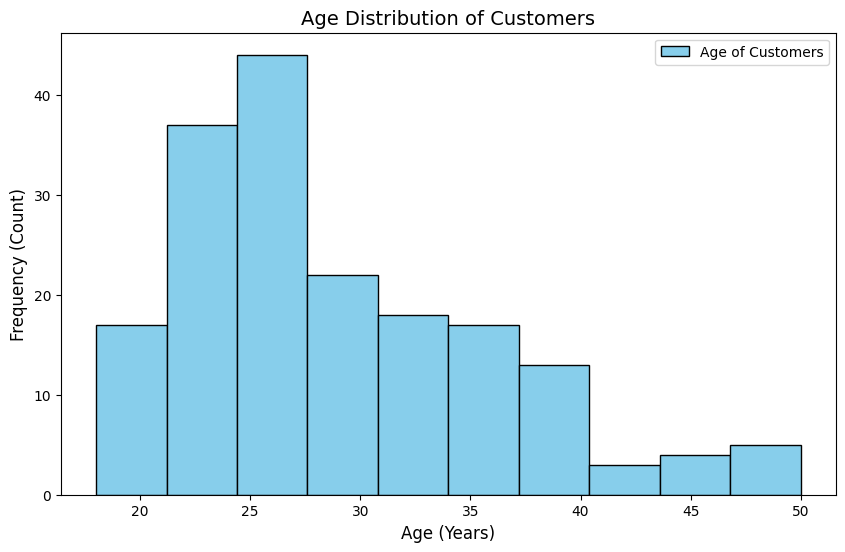

In [6]:
# 1. Extract the Age data
age_data = data['Age']

# 2. Create the histogram with 10 bins
plt.figure(figsize=(10, 6))
plt.hist(age_data, bins=10, color='skyblue', edgecolor='black', label='Age of Customers')

# 3. Add Title and Axis Labels
plt.title('Age Distribution of Customers', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# 4. Add a Legend
plt.legend()

# 5. Save and show the plot
plt.savefig('age_distribution.png')
plt.show()

Analysis_and_Goal = """

  Analysis      
        Median Age: 26.0
        Year Bracket: 25–30
  Goal 
        Key Pattern: Your business has a highly concentrated market of young adults, 
        which should drive your product development and advertising strategies.


"""




**Task 4: Product Popularity.** Create a Count Plot (Bar Chart) showing how many of each Product (TM195, TM498, TM798) were sold.

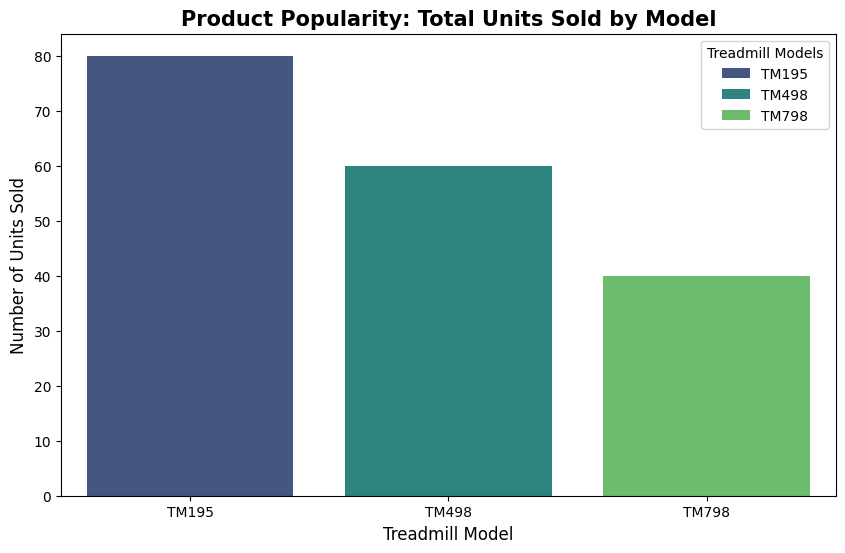

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Product', hue='Product', palette='viridis')
plt.title('Product Popularity: Total Units Sold by Model', fontsize=15, fontweight='bold')
plt.xlabel('Treadmill Model', fontsize=12)
plt.ylabel('Number of Units Sold', fontsize=12)
plt.legend(title="Treadmill Models", labels=['TM195', 'TM498', 'TM798'])
plt.show()

**Task 5: Income vs. Product.** Create a Boxplot comparing Income across the three different Product types.

Analysis: Which product is clearly targeted at the "High Income" segment?

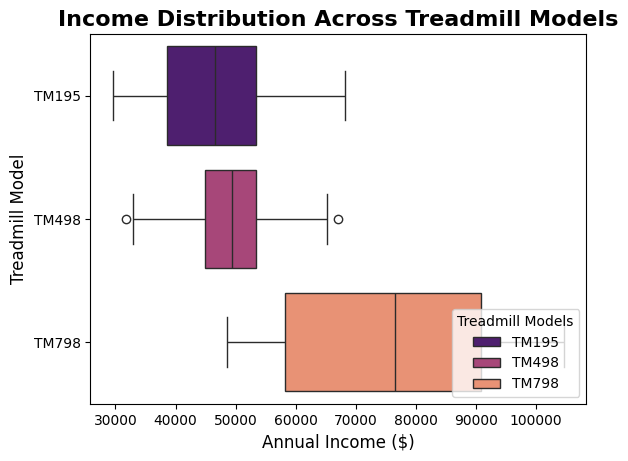

In [8]:
Income = data['Income']
sns.boxplot(data=data, x='Income', y='Product', hue='Product', palette='magma')
plt.title('Income Distribution Across Treadmill Models', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income ($)', fontsize=12)
plt.ylabel('Treadmill Model', fontsize=12)
plt.legend(title="Treadmill Models",labels=['TM195', 'TM498', 'TM798'], loc='lower right')

plt.show()

**Task 6: The Gender Probability.** What is the probability that a customer is Female given that they bought the TM195? (Show your calculation).

Relationship & Regression
Goal: Use math to predict future behavior.

In [9]:
# 1. Define the condition: Customers who bought TM195
tm195_buyers = data[data['Product'] == 'TM195']

# 2. Count the total number of TM195 buyers (Denominator)
total_tm195 = len(tm195_buyers)

# 3. Count the number of Females within the TM195 buyers (Numerator)
female_tm195 = len(tm195_buyers[tm195_buyers['Gender'] == 'Female'])

# 4. Calculate the probability
probability = female_tm195 / total_tm195

# Show calculation steps
print(f"Number of Female TM195 buyers: {female_tm195}")
print(f"Total TM195 buyers: {total_tm195}")
print(f"Calculation: {female_tm195} / {total_tm195}")
print(f"Probability P(Female | TM195) = {probability}")

Number of Female TM195 buyers: 40
Total TM195 buyers: 80
Calculation: 40 / 80
Probability P(Female | TM195) = 0.5


**Task 7: Correlation Heatmap.** Generate a correlation heatmap for all numerical variables.

Analysis: Which variable (Age, Education, or Usage) has the strongest positive correlation with Miles?

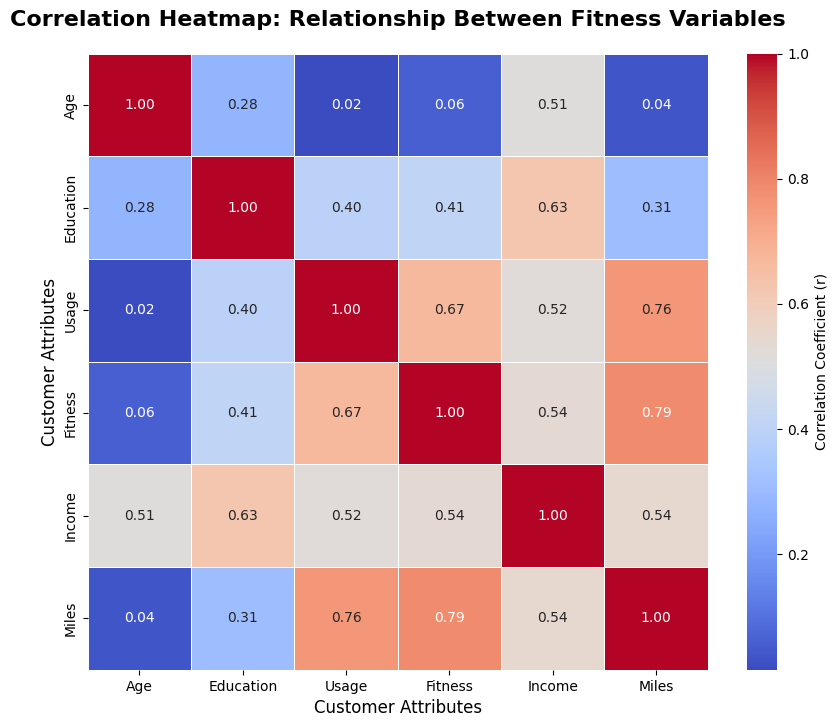

Correlation coefficients with Miles:
Miles        1.000000
Fitness      0.785702
Usage        0.759130
Income       0.543473
Education    0.307284
Age          0.036618
Name: Miles, dtype: float64


In [10]:
# 1. Filter for numerical variables only
numerical_data = data.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numerical_data.corr()

# 3. Generate the heatmap
plt.figure(figsize=(10, 8))
# 4 cbar_kws adds a "label" to the color bar, acting as your legend
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,cbar_kws={'label': 'Correlation Coefficient (r)'})

# 5. Add Title and Axis Labels
plt.title('Correlation Heatmap: Relationship Between Fitness Variables', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Attributes', fontsize=12)
plt.ylabel('Customer Attributes', fontsize=12)
#6 Save and display
plt.savefig('correlation_heatmap.png')
plt.show()

# 5. Display specific correlations with 'Miles' for analysis
print("Correlation coefficients with Miles:")
print(corr_matrix['Miles'].sort_values(ascending=False))

**Task 8: The Scatter Plot.** Create a scatter plot with Usage on the X-axis and Miles on the Y-axis. Add a "Regression Line" (Trendline) to the plot.

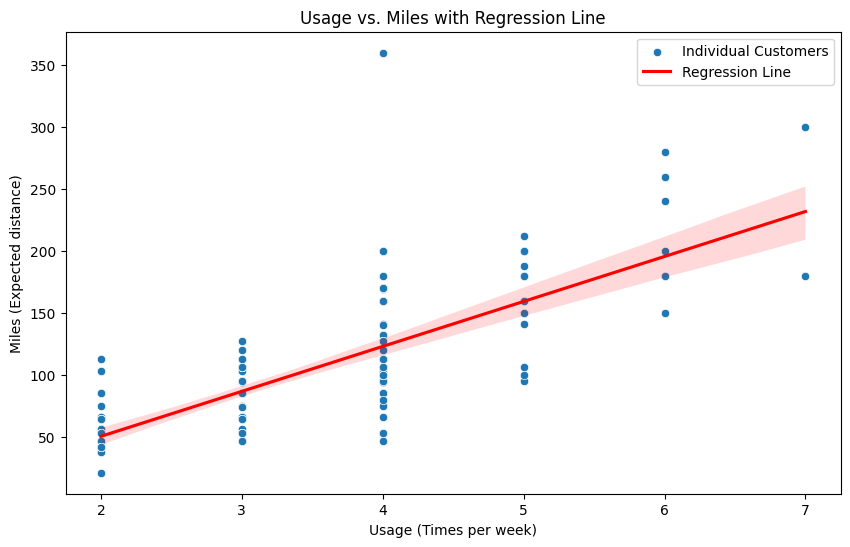

In [11]:
# 1. Create the Scatter Plot using sns.scatterplot()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Usage', y='Miles', label='Individual Customers')

# 2. Add the Regression Line (Trendline)
# We use scatter=False so we don't draw the points twice
sns.regplot(data=data, x='Usage', y='Miles', scatter=False, color='red', label='Regression Line')

# 3. Add labels and title
plt.title('Usage vs. Miles with Regression Line')
plt.xlabel('Usage (Times per week)')
plt.ylabel('Miles (Expected distance)')
plt.legend()

# 4. Save the plot
plt.savefig('scatterplot_usage_miles.png')
plt.show()

**The Final Task**
Create a new subset of data containing only customers with a Fitness Score of 5.

What is the "Average Profile" of an elite athlete in this dataset (Average Age, Education, and Income)?

In [12]:

# 1. Create the subset for Elite Athletes (Fitness Score 5)
elite_athletes = data[data['Fitness'] == 5]

# 2. Calculate the "Average Profile"
avg_age = elite_athletes['Age'].mean()
avg_education = elite_athletes['Education'].mean()
avg_income = elite_athletes['Income'].mean()

# 3. Display the results
print("--- Average Profile of an Elite Athlete (Fitness 5) ---")
print(f"Average Age: {avg_age:.1f} years")
print(f"Average Education: {avg_education:.1f} years")
print(f"Average Income: ${avg_income:,.2f}")


--- Average Profile of an Elite Athlete (Fitness 5) ---
Average Age: 29.8 years
Average Education: 17.1 years
Average Income: $74,396.71
